# REVISE Visium Mouse Cortex Case Notebook

This notebook is a self-contained REVISE case study for a public Visium mouse cortex dataset. It demonstrates the full path from raw spot-level data to reconstructed spatially inferred virtual cells (SVCs) using the unified `REVISEPipeline` API.

Core modules:

1. Inspect the public Visium input data, reference annotations, and histology image.
2. Prepare spot-level Visium data and a scRNA-seq reference in the format expected by REVISE.
3. Estimate virtual cells directly from each spot's transcript abundance. No external cell segmentation workflow is used.
4. Run REVISE through the `application_sc_sr` profile.
5. Review the reconstructed SVC with spatial cell-type maps, composition summaries, and representative gene-expression maps.


## Notebook Guide

**Purpose.** Run a compact Visium mouse brain sc-SVC example through the public REVISEPipeline API.

**Inputs.** Mouse brain Visium inputs under `../../raw_data/visium_mouse_brain/`.

**Outputs.** Prepared inputs, reconstructed SVC file, and six QC/summary figures displayed inline and saved to `../../output/sc_SVC_case_Visium_mouse_brain/figures/`.

**Reading order.**
1. Inspect raw inputs
2. Prepare virtual-cell priors
3. Run revise-svc pipeline
4. Summarize reconstructed cell types and expression structure

**Reproducibility note.** `revise` imports are standard package imports from the installed `revise-svc` distribution; this notebook does not modify `sys.path` to import the repository source tree.


## Minimum REVISE Input For This Case

To run this Visium-style `sc-SVC-sr` case, users only need a spot-level `AnnData` file and a matched scRNA-seq reference. The spatial file should store a spot-by-gene count matrix in `st_adata.X`, gene names in `st_adata.var_names`, and two-dimensional spot coordinates in `st_adata.obsm["spatial"]`. The reference should store a cell-by-gene count matrix in `sc_ref_adata.X`, gene names in `sc_ref_adata.var_names`, and broad cell-type labels in `sc_ref_adata.obs["Level1"]`. The two files only need to share genes by name.

For spot-based `sc-SVC-sr`, `st_adata.uns["all_cells_in_spot"]` can be provided when users have a curated spot-to-cell or spot-to-virtual-cell mapping. If it is missing, REVISE logs a warning and creates a default virtual-cell mapping from spot transcript counts, so a minimal spot-level input can still run.


## Case Design And Assumptions

This dataset is standard spot-based Visium data rather than a high-resolution Visium HD bin matrix. In the current REVISE routing scheme, this maps naturally to the `application_sc_sr` profile: REVISE first anchors spot-level cell-type proportions using the scRNA-seq reference, then allocates spot expression into virtual cells.

The only virtual-cell allocation signal used in this notebook is total transcript abundance per spot. The rule is deliberately simple and transparent: scale transcript counts so that the median positive spot contains about four virtual cells, then clamp the estimate between one and twelve virtual cells per spot. This keeps the case lightweight while preserving the main spatial variation in capture depth.

The figures follow a compact case-study structure: input context, quality control, allocation logic, reconstruction output, and biological inspection.


In [1]:
from __future__ import annotations

import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

from importlib.resources import files
from pathlib import Path
from urllib.request import urlretrieve
import contextlib
import io
import time
import warnings
import yaml

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import Markdown, display
from scipy import sparse

from revise.framework import REVISEPipeline

sc.settings.verbosity = 1
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

COLOR_MAIN = "#0077BB"
COLOR_ACCENT = "#EE7733"
COLOR_GREEN = "#009988"
COLOR_GREY = "#9AA4B2"

version_table = pd.DataFrame(
    [
        ("python", os.sys.version.split()[0]),
        ("numpy", np.__version__),
        ("pandas", pd.__version__),
        ("scanpy", sc.__version__),
        ("matplotlib", mpl.__version__),
    ],
    columns=["component", "version"],
)
display(version_table)


,component,version
0,python,3.9.18
1,numpy,1.24.3
2,pandas,2.2.3
3,scanpy,1.10.3
4,matplotlib,3.9.4


## 1. Configure Paths

Raw files and REVISE-ready inputs are stored under `raw_data/visium_mouse_brain`. Reconstructed artifacts and notebook figures are written to `output/visium_mouse_brain_revise`. The file names are chosen to match the existing REVISE application profile conventions.


In [2]:
SAMPLE_NAME = "REVISEVisiumMouseBrain"
DATA_ROOT = Path("raw_data/visium_mouse_brain")
OUTPUT_ROOT = Path("output/visium_mouse_brain_revise")
FIGURE_DIR = OUTPUT_ROOT / "notebook_figures"

KEY_TYPE = "celltype"
ST_FILE = "ST_mouse_brain_prepared.h5ad"
SC_REF_FILE = "scRNA_mouse_brain_prepared.h5ad"

RAW_SC_PATH = DATA_ROOT / "scRNA_mouse_brain.h5ad"
RAW_ST_PATH = DATA_ROOT / "ST_mouse_brain.h5ad"
RAW_IMG_PATH = DATA_ROOT / "img_mouse_brain.png"

PREPARED_ST_PATH = DATA_ROOT / f"{SAMPLE_NAME}_{ST_FILE}"
PREPARED_SC_PATH = DATA_ROOT / SC_REF_FILE
PM_ON_CELL_PATH = DATA_ROOT / "PM_on_cell.csv"

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

path_table = pd.DataFrame(
    [
        ("raw scRNA reference", RAW_SC_PATH),
        ("raw Visium spots", RAW_ST_PATH),
        ("raw histology image", RAW_IMG_PATH),
        ("prepared Visium input", PREPARED_ST_PATH),
        ("prepared scRNA reference", PREPARED_SC_PATH),
        ("virtual-cell prior", PM_ON_CELL_PATH),
        ("notebook figures", FIGURE_DIR),
    ],
    columns=["asset", "path"],
)
path_table["exists_now"] = path_table["path"].map(lambda p: Path(p).exists())
display(path_table)


,asset,path,exists_now
0,raw scRNA reference,raw_data/visium_mouse_brain/scRNA_mouse_brain....,True
1,raw Visium spots,raw_data/visium_mouse_brain/ST_mouse_brain.h5ad,True
2,raw histology image,raw_data/visium_mouse_brain/img_mouse_brain.png,True
3,prepared Visium input,raw_data/visium_mouse_brain/REVISEVisiumMouseB...,True
4,prepared scRNA reference,raw_data/visium_mouse_brain/scRNA_mouse_brain_...,True
5,virtual-cell prior,raw_data/visium_mouse_brain/PM_on_cell.csv,True
6,notebook figures,output/visium_mouse_brain_revise/notebook_figures,True


## 2. Fetch The Input Files

The notebook downloads three public files if they are not already present: a scRNA-seq reference, a Visium spot AnnData object, and the paired H&E image. Re-running the cell is safe because existing files are reused.


In [3]:
DATA_REPOSITORY = "jyyulab/" + "Spot" + "iphy"
RAW_BASE_URL = f"https://raw.githubusercontent.com/{DATA_REPOSITORY}/main/tutorials/data"
URLS = {
    RAW_SC_PATH: f"{RAW_BASE_URL}/scRNA_mouse_brain.h5ad",
    RAW_ST_PATH: f"{RAW_BASE_URL}/ST_mouse_brain.h5ad",
    RAW_IMG_PATH: f"{RAW_BASE_URL}/img_mouse_brain.png",
}

records = []
for path, url in URLS.items():
    if path.exists():
        status = "reused"
    else:
        urlretrieve(url, path)
        status = "downloaded"
    records.append(
        {
            "file": path.name,
            "status": status,
            "size_mb": round(path.stat().st_size / 1024**2, 2),
            "path": str(path),
        }
    )

display(pd.DataFrame(records))


,file,status,size_mb,path
0,scRNA_mouse_brain.h5ad,reused,97.61,raw_data/visium_mouse_brain/scRNA_mouse_brain....
1,ST_mouse_brain.h5ad,reused,9.70,raw_data/visium_mouse_brain/ST_mouse_brain.h5ad
2,img_mouse_brain.png,reused,15.24,raw_data/visium_mouse_brain/img_mouse_brain.png


## 3. Load Data And Audit Contents

Before reconstruction, the notebook checks the dimensions, annotation columns, spatial coordinates, and transcript-count distribution. These checks catch the most common input problems early, before launching the full REVISE run.


In [4]:
adata_sc_raw = sc.read_h5ad(RAW_SC_PATH)
adata_st_raw = sc.read_h5ad(RAW_ST_PATH)
image = plt.imread(RAW_IMG_PATH)

adata_sc_raw.var_names_make_unique()
adata_st_raw.var_names_make_unique()

if "spatial" not in adata_st_raw.obsm:
    raise KeyError("Expected adata_st_raw.obsm['spatial'] for Visium spot coordinates")
if KEY_TYPE not in adata_sc_raw.obs:
    raise KeyError(f"Expected adata_sc_raw.obs['{KEY_TYPE}'] in the scRNA reference")

st_total = np.asarray(adata_st_raw.X.sum(axis=1)).ravel()
adata_st_raw.obs["transcript_counts"] = st_total

type_list = sorted(adata_sc_raw.obs[KEY_TYPE].astype(str).unique())

audit_table = pd.DataFrame(
    [
        ("Visium spots", adata_st_raw.n_obs, adata_st_raw.n_vars, "spot matrix"),
        ("scRNA reference", adata_sc_raw.n_obs, adata_sc_raw.n_vars, "cell matrix"),
        ("H&E image", image.shape[0], image.shape[1], f"{image.shape[-1]} channels"),
        ("cell-type labels", len(type_list), np.nan, KEY_TYPE),
    ],
    columns=["item", "rows_or_count", "features_or_width", "note"],
)
transcript_summary = pd.Series(st_total, name="transcripts_per_spot").describe().to_frame()

display(audit_table)
display(transcript_summary)


,item,rows_or_count,features_or_width,note
0,Visium spots,685,32285.0,spot matrix
1,scRNA reference,10500,33526.0,cell matrix
2,H&E image,4100,2600.0,3 channels
3,cell-type labels,14,NaN,celltype


,transcripts_per_spot
count,685.000000
mean,13680.651367
std,8232.467773
min,623.000000
25%,6703.000000
50%,12618.000000
75%,18891.000000
max,44149.000000


**Figure 1 saved:** `output/visium_mouse_brain_revise/notebook_figures/01_input_qc.png`

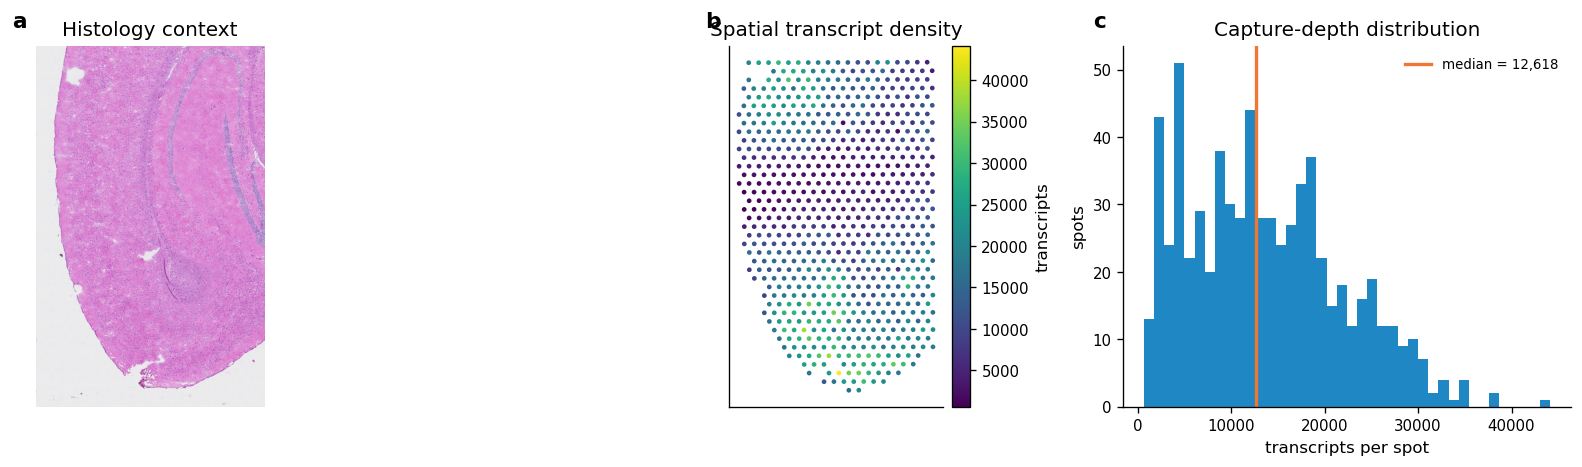

In [5]:
def add_panel_label(ax, label):
    ax.text(
        -0.04,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="bottom",
        ha="right",
    )


def plot_spatial_points(adata, values, ax, title, cmap="viridis", point_size=8):
    coords = np.asarray(adata.obsm["spatial"])
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=values, s=point_size, cmap=cmap, linewidths=0)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    return scatter

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image)
axes[0].set_title("Histology context")
axes[0].axis("off")
add_panel_label(axes[0], "a")

scatter = plot_spatial_points(
    adata_st_raw,
    adata_st_raw.obs["transcript_counts"],
    axes[1],
    "Spatial transcript density",
    cmap="viridis",
)
plt.colorbar(scatter, ax=axes[1], fraction=0.046, pad=0.02, label="transcripts")
add_panel_label(axes[1], "b")

axes[2].hist(adata_st_raw.obs["transcript_counts"], bins=40, color=COLOR_MAIN, alpha=0.88)
median_count = float(np.median(adata_st_raw.obs["transcript_counts"]))
axes[2].axvline(median_count, color=COLOR_ACCENT, linewidth=2, label=f"median = {median_count:,.0f}")
axes[2].set_title("Capture-depth distribution")
axes[2].set_xlabel("transcripts per spot")
axes[2].set_ylabel("spots")
axes[2].legend(frameon=False)
add_panel_label(axes[2], "c")

plt.tight_layout()
figure_path = FIGURE_DIR / "01_input_qc.png"
plt.savefig(figure_path, bbox_inches="tight")
display(Markdown(f"**Figure 1 saved:** `{figure_path}`"))
plt.show()


## 4. Build REVISE-Ready Input Objects

The REVISE application route expects broad and fine cell-type labels in `Level1` and `Level2`. The reference annotation column `celltype` is copied into both fields, and also into `clusters`, so that all downstream routing logic sees a consistent annotation schema.

The Visium and scRNA matrices are then restricted to common genes. This mirrors the usual reference-guided spatial reconstruction setup: only genes observed in both modalities can be used for anchoring and allocation.


In [6]:
adata_st = adata_st_raw.copy()
adata_sc = adata_sc_raw.copy()

adata_st.obsm["spatial"] = np.asarray(adata_st.obsm["spatial"]).astype(np.int32)
adata_st.obs["transcript_counts"] = np.asarray(adata_st.X.sum(axis=1)).ravel()

labels = adata_sc.obs[KEY_TYPE].astype(str).str.replace("/", "_", regex=False)
adata_sc.obs["Level1"] = labels
adata_sc.obs["Level2"] = labels
adata_sc.obs["clusters"] = labels

common_genes = adata_st.var_names.intersection(adata_sc.var_names)
if len(common_genes) == 0:
    raise ValueError("No common genes between Visium spots and scRNA reference")

adata_st = adata_st[:, common_genes].copy()
adata_sc = adata_sc[:, common_genes].copy()

prep_summary = pd.DataFrame(
    [
        ("common genes", len(common_genes)),
        ("prepared Visium spots", adata_st.n_obs),
        ("prepared Visium genes", adata_st.n_vars),
        ("prepared reference cells", adata_sc.n_obs),
        ("prepared reference genes", adata_sc.n_vars),
        ("reference cell types", adata_sc.obs["Level1"].nunique()),
    ],
    columns=["metric", "value"],
)
cell_type_table = (
    adata_sc.obs["Level1"]
    .value_counts()
    .rename_axis("cell_type")
    .reset_index(name="reference_cells")
)
cell_type_table["fraction"] = cell_type_table["reference_cells"] / cell_type_table["reference_cells"].sum()

display(prep_summary)
display(cell_type_table)


,metric,value
0,common genes,32245
1,prepared Visium spots,685
2,prepared Visium genes,32245
3,prepared reference cells,10500
4,prepared reference genes,32245
5,reference cell types,14


,cell_type,reference_cells,fraction
0,Astro,750,0.071429
1,CA,750,0.071429
2,DG,750,0.071429
3,L2_3 IT CTX,750,0.071429
4,L4 IT CTX,750,0.071429
5,L4_5 IT CTX,750,0.071429
6,L5 IT CTX,750,0.071429
7,L5 PT CTX,750,0.071429
8,L5_6 IT CTX,750,0.071429
9,L6 CT CTX,750,0.071429


## 5. Allocate Virtual Cells From Transcript Abundance

This section estimates the number of virtual cells per spot with a transparent transcript-count rule:

1. Compute total transcript counts per Visium spot.
2. Scale counts so that the median positive spot maps to about four virtual cells.
3. Clamp the estimate to the interval `[1, 12]` to keep the case lightweight and prevent a few high-depth spots from dominating the reconstruction.

The resulting spot-to-virtual-cell mapping is written to `adata_st.uns['all_cells_in_spot']`, which is consumed by the REVISE spot-level reconstruction path.


In [7]:
def estimate_virtual_cells_from_transcripts(
    adata,
    target_median_cells=4,
    min_cells=1,
    max_cells=12,
):
    counts = np.asarray(adata.obs["transcript_counts"], dtype=float)
    positive = counts[counts > 0]
    if positive.size == 0:
        raise ValueError("All spots have zero transcript counts")

    scale = max(float(np.median(positive)) / float(target_median_cells), 1.0)
    n_cells = np.rint(counts / scale).astype(int)
    n_cells = np.clip(n_cells, int(min_cells), int(max_cells))

    all_cells_in_spot = {}
    for spot_name, n_cell in zip(adata.obs_names.astype(str), n_cells):
        all_cells_in_spot[spot_name] = np.asarray(
            [f"{spot_name}_vc_{idx:02d}" for idx in range(int(n_cell))],
            dtype=str,
        )
    return n_cells, all_cells_in_spot, scale

estimated_cell_count, all_cells_in_spot, transcript_scale = estimate_virtual_cells_from_transcripts(adata_st)
adata_st.obs["estimated_cell_count"] = estimated_cell_count
adata_st.uns["all_cells_in_spot"] = all_cells_in_spot

virtual_cell_ids = [cell_id for cells in all_cells_in_spot.values() for cell_id in cells]
allocation_summary = pd.DataFrame(
    [
        ("transcripts per virtual-cell unit", round(transcript_scale, 2)),
        ("spots", adata_st.n_obs),
        ("total virtual cells", len(virtual_cell_ids)),
        ("median virtual cells per spot", float(np.median(estimated_cell_count))),
        ("minimum virtual cells per spot", int(np.min(estimated_cell_count))),
        ("maximum virtual cells per spot", int(np.max(estimated_cell_count))),
    ],
    columns=["metric", "value"],
)
allocation_counts = (
    pd.Series(estimated_cell_count, name="virtual_cells_per_spot")
    .value_counts()
    .sort_index()
    .rename_axis("virtual_cells_per_spot")
    .reset_index(name="spots")
)

display(allocation_summary)
display(allocation_counts)


,metric,value
0,transcripts per virtual-cell unit,3154.5
1,spots,685.0
2,total virtual cells,2979.0
3,median virtual cells per spot,4.0
4,minimum virtual cells per spot,1.0
5,maximum virtual cells per spot,12.0


,virtual_cells_per_spot,spots
0,1,122
1,2,75
2,3,89
3,4,96
4,5,83
5,6,80
6,7,42
7,8,47
8,9,30
9,10,13


**Figure 2 saved:** `output/visium_mouse_brain_revise/notebook_figures/02_virtual_cell_allocation.png`

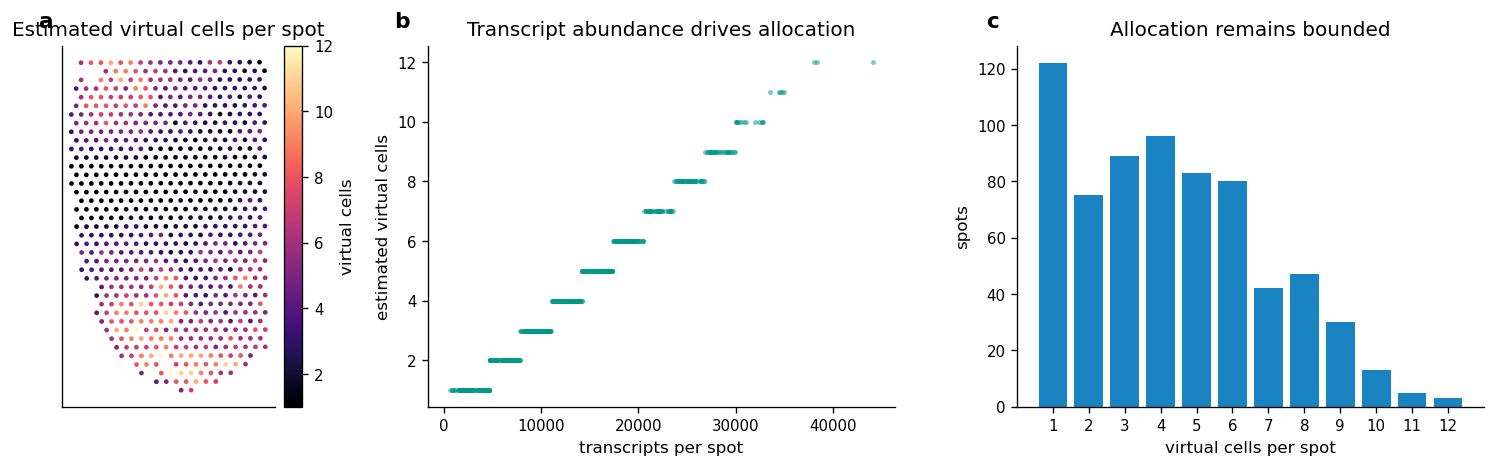

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scatter = plot_spatial_points(
    adata_st,
    adata_st.obs["estimated_cell_count"],
    axes[0],
    "Estimated virtual cells per spot",
    cmap="magma",
)
plt.colorbar(scatter, ax=axes[0], fraction=0.046, pad=0.02, label="virtual cells")
add_panel_label(axes[0], "a")

axes[1].scatter(
    adata_st.obs["transcript_counts"],
    adata_st.obs["estimated_cell_count"],
    s=9,
    alpha=0.5,
    color=COLOR_GREEN,
    linewidths=0,
)
axes[1].set_title("Transcript abundance drives allocation")
axes[1].set_xlabel("transcripts per spot")
axes[1].set_ylabel("estimated virtual cells")
add_panel_label(axes[1], "b")

axes[2].bar(
    allocation_counts["virtual_cells_per_spot"].astype(str),
    allocation_counts["spots"],
    color=COLOR_MAIN,
    alpha=0.9,
)
axes[2].set_title("Allocation remains bounded")
axes[2].set_xlabel("virtual cells per spot")
axes[2].set_ylabel("spots")
add_panel_label(axes[2], "c")

plt.tight_layout()
figure_path = FIGURE_DIR / "02_virtual_cell_allocation.png"
plt.savefig(figure_path, bbox_inches="tight")
display(Markdown(f"**Figure 2 saved:** `{figure_path}`"))
plt.show()


## 6. Save Prepared Inputs And The Virtual-Cell Prior

`PM_on_cell.csv` is a lightweight prior over cell types for each virtual cell. It is initialized from global cell-type abundance in the scRNA-seq reference and receives a tiny deterministic jitter to avoid exact ties. The later REVISE steps combine this prior with spot-level anchoring to assign virtual cells to specific cell types.


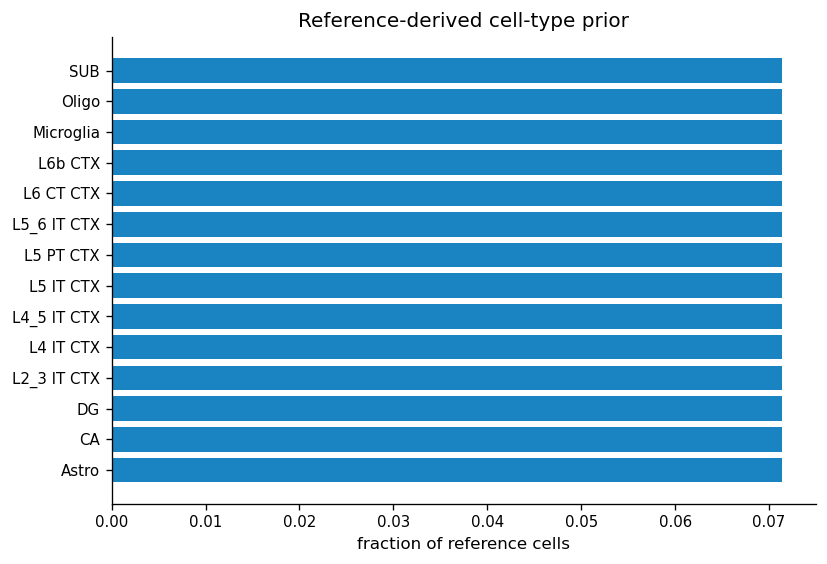

,asset,path,size_mb
0,prepared Visium input,raw_data/visium_mouse_brain/REVISEVisiumMouseB...,33.07
1,prepared scRNA reference,raw_data/visium_mouse_brain/scRNA_mouse_brain_...,485.20
2,virtual-cell prior,raw_data/visium_mouse_brain/PM_on_cell.csv,0.86


**Figure 3 saved:** `output/visium_mouse_brain_revise/notebook_figures/03_reference_prior.png`

In [9]:
cell_types = sorted(adata_sc.obs["Level1"].astype(str).unique())
cell_type_prior = (
    adata_sc.obs["Level1"]
    .astype(str)
    .value_counts(normalize=True)
    .reindex(cell_types, fill_value=0.0)
)

rng = np.random.default_rng(42)
pm_on_cell = pd.DataFrame(
    np.tile(cell_type_prior.to_numpy(), (len(virtual_cell_ids), 1)),
    index=virtual_cell_ids,
    columns=cell_types,
)
pm_on_cell += rng.uniform(0, 1e-6, size=pm_on_cell.shape)
pm_on_cell = pm_on_cell.div(pm_on_cell.sum(axis=1), axis=0)

adata_st.write_h5ad(PREPARED_ST_PATH)
adata_sc.write_h5ad(PREPARED_SC_PATH)
pm_on_cell.to_csv(PM_ON_CELL_PATH)

file_table = pd.DataFrame(
    [
        ("prepared Visium input", PREPARED_ST_PATH),
        ("prepared scRNA reference", PREPARED_SC_PATH),
        ("virtual-cell prior", PM_ON_CELL_PATH),
    ],
    columns=["asset", "path"],
)
file_table["size_mb"] = file_table["path"].map(lambda p: round(Path(p).stat().st_size / 1024**2, 2))

prior_table = cell_type_prior.sort_values(ascending=False).rename("prior_fraction").reset_index()
prior_table = prior_table.rename(columns={"Level1": "cell_type", "index": "cell_type"})

fig, ax = plt.subplots(figsize=(7, 4.8))
plot_prior = prior_table.sort_values("prior_fraction", ascending=True)
ax.barh(plot_prior["cell_type"], plot_prior["prior_fraction"], color=COLOR_MAIN, alpha=0.9)
ax.set_title("Reference-derived cell-type prior")
ax.set_xlabel("fraction of reference cells")
ax.set_ylabel("")
plt.tight_layout()
figure_path = FIGURE_DIR / "03_reference_prior.png"
plt.savefig(figure_path, bbox_inches="tight")
plt.show()

display(file_table)
display(Markdown(f"**Figure 3 saved:** `{figure_path}`"))
plt.show()


## 7. Run REVISE Reconstruction

The next cell calls the unified REVISE API. The thresholds are intentionally moderate because this is a runnable case notebook rather than a large-scale benchmark. The graph is built with PCA neighbors for a dependency-light and reproducible default route.


In [10]:
start_time = time.time()
stdout_buffer = io.StringIO()
stderr_buffer = io.StringIO()

case_config = yaml.safe_load(files("revise").joinpath("revise.yaml").read_text(encoding="utf-8"))
case_profile = case_config["profiles"]["application_sc_sr"]
case_profile.setdefault("preprocess", {}).update({
    "st_min_transcripts": 20,
    "st_min_cells": 20,
    "sc_min_cells": 20,
})
case_profile.setdefault("graph", {}).update({
    "method": "pca",
    "n_neighbors": 10,
    "exp_neighbors": 10,
    "spatial_neighbors": 10,
})
case_profile.setdefault("sc", {}).update({"match_spot_sum": True})
case_config_path = OUTPUT_ROOT / "revise-visium-mouse-brain.yaml"
case_config_path.write_text(yaml.safe_dump(case_config, sort_keys=False), encoding="utf-8")

with warnings.catch_warnings(), contextlib.redirect_stdout(stdout_buffer), contextlib.redirect_stderr(stderr_buffer):
    warnings.simplefilter("ignore")
    pipeline = REVISEPipeline(config_path=str(case_config_path))
    svc = pipeline.run(
        profile="application_sc_sr",
        runtime_overrides={
            "platform": "sc_svc_sr",
            "confounding": "spot_size",
        },
        io_overrides={
            "data_root": str(DATA_ROOT),
            "output_root": str(OUTPUT_ROOT),
            "sample_name": SAMPLE_NAME,
            "st_file": ST_FILE,
            "sc_ref_file": SC_REF_FILE,
        },
        dry_run=False,
    )

elapsed_seconds = time.time() - start_time
summary = svc.summary()
run_dir = Path(svc.provenance["run_dir"])
run_summary = pd.DataFrame(
    [
        ("profile", "application_sc_sr"),
        ("platform", "sc_svc_sr"),
        ("runtime_seconds", round(elapsed_seconds, 1)),
        ("run_directory", str(run_dir)),
        ("summary_keys", ", ".join(sorted(summary.keys()))),
    ],
    columns=["metric", "value"],
)

captured_lines = (stdout_buffer.getvalue() + "\n" + stderr_buffer.getvalue()).splitlines()
info_lines = [line for line in captured_lines if "[INFO]" in line or "[pipeline]" in line]
log_tail = "\n".join(info_lines[-10:]) if info_lines else "No concise pipeline log lines were captured."

display(run_summary)
display(Markdown("**Pipeline log tail**\n\n```text\n" + log_tail + "\n```"))


,metric,value
0,profile,application_sc_sr
1,platform,sc_svc_sr
2,runtime_seconds,21.6
3,run_directory,output/visium_mouse_brain_revise/REVISEVisiumM...
4,summary_keys,"artifact_keys, n_obs, n_vars, quality_metric_k..."


**Pipeline log tail**

```text
[2026-05-13 07:11:40] [INFO] [sc_svc_sr_application.py:95] Extracted SVC expressions using simple allocation method
[2026-05-13 07:11:40] [INFO] [sc_svc_sr_application.py:99] Applying OT-based neighbor enhancement among single cells
[2026-05-13 07:11:50] [INFO] [sc_svc_sr_application.py:195] Number of cells processed: 2979
[2026-05-13 07:11:50] [INFO] [sc_svc_sr_application.py:196] Number of unique spots: 685
[2026-05-13 07:11:50] [INFO] [sc_svc_sr_application.py:197] Shape of SVC_X: (2979, 12560)
[2026-05-13 07:11:50] [INFO] [pipeline.py:62] [pipeline] stage=update_expression
[2026-05-13 07:11:50] [INFO] [pipeline.py:62] [pipeline] stage=finalize_svc
[2026-05-13 07:11:51] [INFO] [pipeline.py:62] [pipeline] stage=evaluate_if_needed
[2026-05-13 07:11:51] [INFO] [pipeline.py:101] [pipeline] evaluation skipped by policy
[2026-05-13 07:11:51] [INFO] [framework.py:155] [framework] finished unified run route=sc_svc_sr:spot_size
```

## 8. Inspect The Reconstructed SVC Object

For this route, the main result is `sc_svc_dec`: a virtual-cell AnnData object with reconstructed expression, spot-derived coordinates, and REVISE-assigned cell types.


In [11]:
artifact_path = run_dir / "artifacts" / "sc_svc_dec.h5ad"
legacy_path = run_dir / "sc_SVC.h5ad"

svc_adata = svc.expr.copy() if svc.expr is not None else sc.read_h5ad(artifact_path)
svc_adata.obsm["spatial"] = svc_adata.obs[["x", "y"]].to_numpy(dtype=float)

svc_metrics = pd.DataFrame(
    [
        ("virtual cells", svc_adata.n_obs),
        ("genes", svc_adata.n_vars),
        ("assigned cell types", svc_adata.obs["cell_type"].astype(str).nunique()),
        ("source spots", svc_adata.obs["spot_name"].astype(str).nunique()),
        ("canonical artifact", str(artifact_path)),
        ("legacy-compatible artifact", str(legacy_path)),
    ],
    columns=["metric", "value"],
)
obs_preview = svc_adata.obs[["cell_type", "spot_name", "x", "y"]].head(8)
cell_type_counts = (
    svc_adata.obs["cell_type"]
    .astype(str)
    .value_counts()
    .rename_axis("cell_type")
    .reset_index(name="virtual_cells")
)
cell_type_counts["fraction"] = cell_type_counts["virtual_cells"] / cell_type_counts["virtual_cells"].sum()

display(svc_metrics)
display(obs_preview)
display(cell_type_counts)


,metric,value
0,virtual cells,2979
1,genes,12560
2,assigned cell types,14
3,source spots,685
4,canonical artifact,output/visium_mouse_brain_revise/REVISEVisiumM...
5,legacy-compatible artifact,output/visium_mouse_brain_revise/REVISEVisiumM...


,cell_type,spot_name,x,y
cell_id,,,,
AAACACCAATAACTGC-1_vc_00,L4_5 IT CTX,AAACACCAATAACTGC-1,1198,2420
AAACACCAATAACTGC-1_vc_01,L6 CT CTX,AAACACCAATAACTGC-1,1198,2420
AAACACCAATAACTGC-1_vc_02,SUB,AAACACCAATAACTGC-1,1198,2420
AAACACCAATAACTGC-1_vc_03,L6b CTX,AAACACCAATAACTGC-1,1198,2420
AAACACCAATAACTGC-1_vc_04,L5 PT CTX,AAACACCAATAACTGC-1,1198,2420
AAACACCAATAACTGC-1_vc_05,DG,AAACACCAATAACTGC-1,1198,2420
AAACAGCTTTCAGAAG-1_vc_00,DG,AAACAGCTTTCAGAAG-1,631,857
AAACAGCTTTCAGAAG-1_vc_01,L4_5 IT CTX,AAACAGCTTTCAGAAG-1,631,857


,cell_type,virtual_cells,fraction
0,Astro,1097,0.368244
1,L5 IT CTX,240,0.080564
2,L5 PT CTX,236,0.079221
3,L6b CTX,204,0.068479
4,SUB,186,0.062437
5,L5_6 IT CTX,179,0.060087
6,L6 CT CTX,171,0.057402
7,L4_5 IT CTX,130,0.043639
8,L4 IT CTX,107,0.035918
9,Oligo,106,0.035582


## 9. Spatial Layout Of Reconstructed Cell Types

Multiple virtual cells can share the same original spot center because this notebook does not infer cell boundaries from images. The plot should therefore be read as a REVISE virtual-cell reconstruction on top of spot-level geometry, not as a physical segmentation map.


**Figure 4 saved:** `output/visium_mouse_brain_revise/notebook_figures/04_revise_cell_type_layout.png`

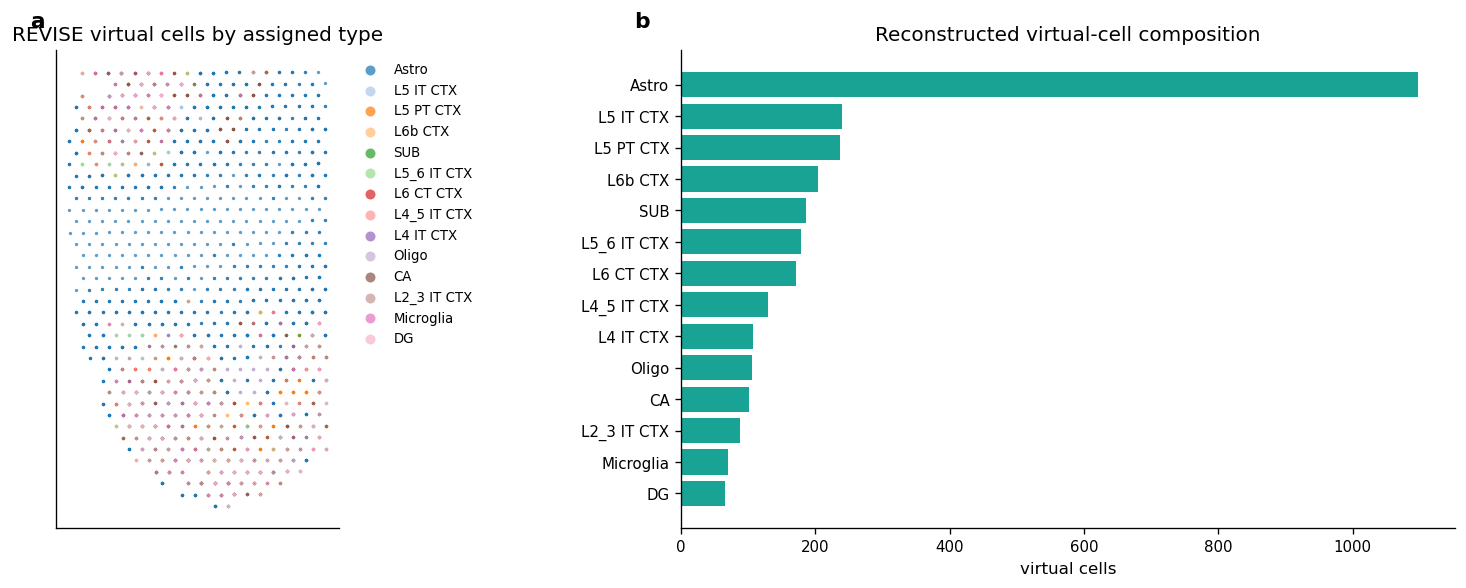

In [12]:
def plot_virtual_cells_by_type(adata, ax, max_legend_types=18, point_size=4):
    obs = adata.obs.copy()
    obs["cell_type"] = obs["cell_type"].astype(str)
    counts = obs["cell_type"].value_counts()
    ordered_types = counts.index.tolist()
    palette = plt.get_cmap("tab20").colors

    for idx, cell_type in enumerate(ordered_types):
        part = obs[obs["cell_type"] == cell_type]
        ax.scatter(
            part["x"],
            part["y"],
            s=point_size,
            alpha=0.72,
            color=palette[idx % len(palette)],
            label=cell_type,
            linewidths=0,
        )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("REVISE virtual cells by assigned type")
    if len(ordered_types) <= max_legend_types:
        ax.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_virtual_cells_by_type(svc_adata, axes[0])
add_panel_label(axes[0], "a")

plot_counts = cell_type_counts.sort_values("virtual_cells", ascending=True)
axes[1].barh(plot_counts["cell_type"], plot_counts["virtual_cells"], color=COLOR_GREEN, alpha=0.9)
axes[1].set_title("Reconstructed virtual-cell composition")
axes[1].set_xlabel("virtual cells")
axes[1].set_ylabel("")
add_panel_label(axes[1], "b")

plt.tight_layout()
figure_path = FIGURE_DIR / "04_revise_cell_type_layout.png"
plt.savefig(figure_path, bbox_inches="tight")
display(Markdown(f"**Figure 4 saved:** `{figure_path}`"))
plt.show()


## 10. Representative Reconstructed Gene Maps

The marker list contains common mouse brain genes. Genes absent from the current matrix are skipped automatically, which keeps the notebook robust to small changes in the public input files.


,gene,mean_expression,nonzero_fraction,p99_expression
0,Snap25,21.482516,1.000000,53.943100
1,Slc17a7,5.098511,1.000000,14.137832
2,Gad1,2.496688,1.000000,20.240637
3,Aqp4,6.177204,0.811010,45.517108
4,Mbp,23.765429,1.000000,665.619632
5,C1qa,0.652996,0.632427,23.300546


**Figure 5 saved:** `output/visium_mouse_brain_revise/notebook_figures/05_reconstructed_gene_maps.png`

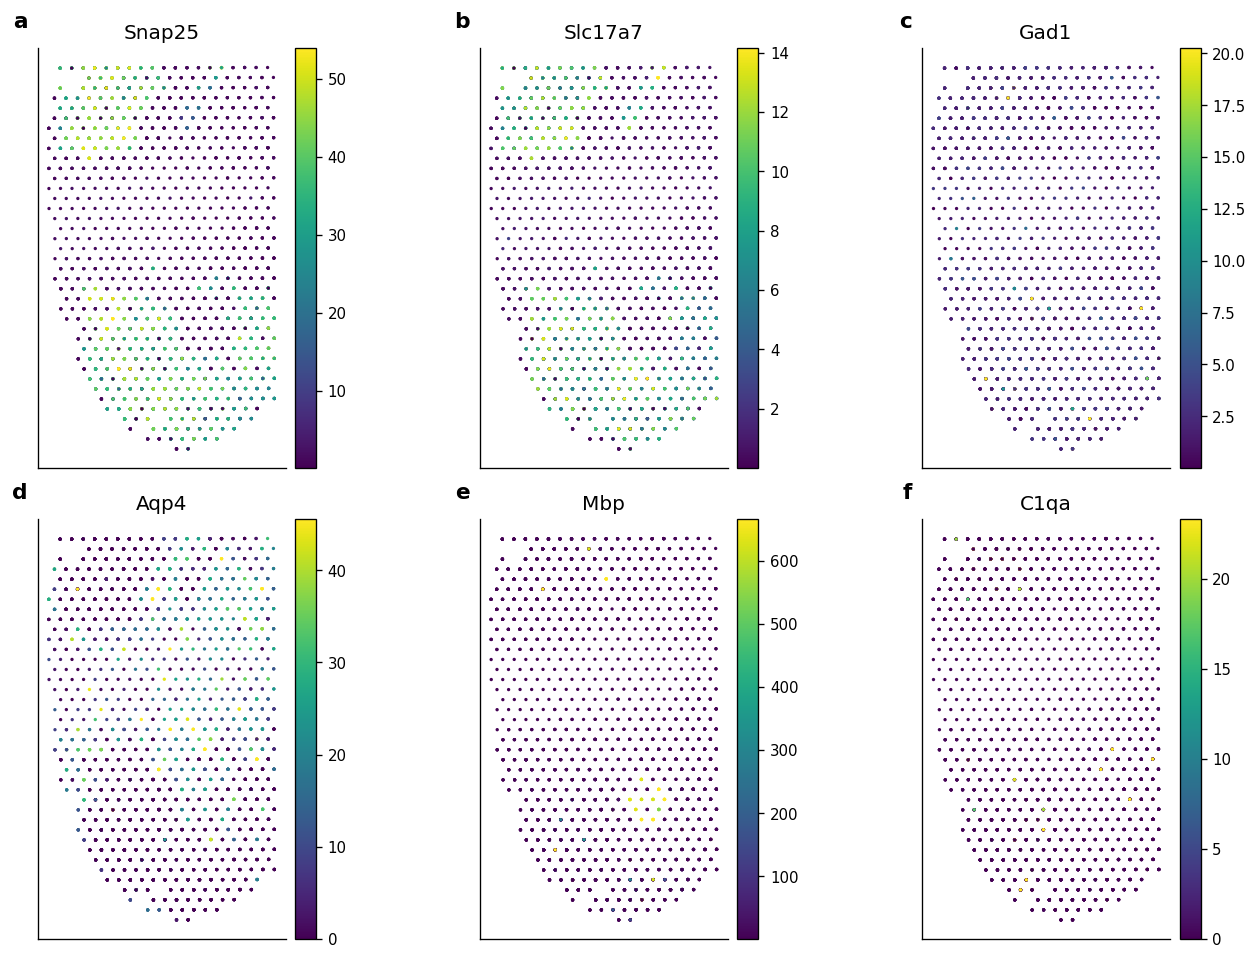

In [13]:
def expression_vector(adata, gene):
    values = adata[:, gene].X
    if sparse.issparse(values):
        values = values.toarray()
    return np.asarray(values).ravel()

candidate_markers = ["Snap25", "Slc17a7", "Gad1", "Aqp4", "Mbp", "C1qa", "Reln", "Pcp4"]
marker_genes = [gene for gene in candidate_markers if gene in svc_adata.var_names][:6]
if not marker_genes:
    marker_genes = list(svc_adata.var_names[: min(6, svc_adata.n_vars)])

marker_summary = []
for gene in marker_genes:
    values = expression_vector(svc_adata, gene)
    marker_summary.append(
        {
            "gene": gene,
            "mean_expression": float(np.mean(values)),
            "nonzero_fraction": float(np.mean(values > 0)),
            "p99_expression": float(np.quantile(values, 0.99)),
        }
    )
marker_summary = pd.DataFrame(marker_summary)
display(marker_summary)

ncols = 3
nrows = int(np.ceil(len(marker_genes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()
coords = svc_adata.obsm["spatial"]

for idx, (ax, gene) in enumerate(zip(axes, marker_genes)):
    values = expression_vector(svc_adata, gene)
    vmax = np.quantile(values, 0.99) if np.any(values) else 1.0
    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=np.clip(values, 0, vmax),
        s=4,
        cmap="viridis",
        linewidths=0,
    )
    ax.set_title(gene)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    add_panel_label(ax, chr(ord("a") + idx))
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02)

for ax in axes[len(marker_genes):]:
    ax.axis("off")

plt.tight_layout()
figure_path = FIGURE_DIR / "05_reconstructed_gene_maps.png"
plt.savefig(figure_path, bbox_inches="tight")
display(Markdown(f"**Figure 5 saved:** `{figure_path}`"))
plt.show()


## 11. Expression-Space Overview

The spatial figures show where reconstructed virtual cells are placed. This PCA view checks whether the reconstructed expression matrix also carries cell-type structure in expression space.


,metric,value
0,cells used,2979.0000
1,highly variable genes used,2000.0000
2,principal components,30.0000
3,PC1 variance ratio,0.3785
4,PC2 variance ratio,0.1183


**Figure 6 saved:** `output/visium_mouse_brain_revise/notebook_figures/06_expression_space_pca.png`

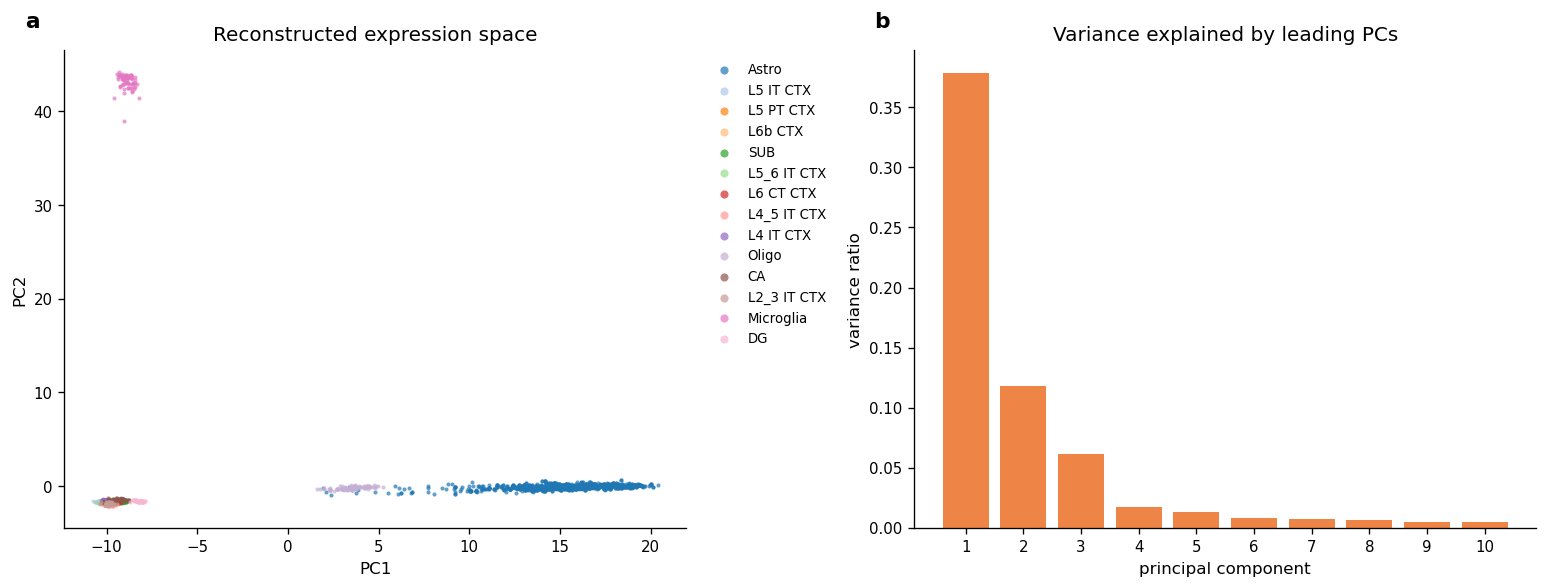

In [14]:
svc_embed = svc_adata.copy()
sc.pp.normalize_total(svc_embed, target_sum=1e4)
sc.pp.log1p(svc_embed)
n_top_genes = min(2000, svc_embed.n_vars)
if n_top_genes >= 50:
    sc.pp.highly_variable_genes(svc_embed, n_top_genes=n_top_genes, subset=True)

n_comps = min(30, svc_embed.n_obs - 1, svc_embed.n_vars - 1)
sc.pp.pca(svc_embed, n_comps=n_comps, random_state=42)

pca_coords = svc_embed.obsm["X_pca"][:, :2]
var_ratio = svc_embed.uns["pca"]["variance_ratio"][: min(10, n_comps)]
pca_summary = pd.DataFrame(
    [
        ("cells used", svc_embed.n_obs),
        ("highly variable genes used", svc_embed.n_vars),
        ("principal components", n_comps),
        ("PC1 variance ratio", round(float(var_ratio[0]), 4)),
        ("PC2 variance ratio", round(float(var_ratio[1]), 4)),
    ],
    columns=["metric", "value"],
)
display(pca_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
obs = svc_embed.obs.copy()
obs["cell_type"] = obs["cell_type"].astype(str)
ordered_types = obs["cell_type"].value_counts().index.tolist()
palette = plt.get_cmap("tab20").colors
for idx, cell_type in enumerate(ordered_types):
    mask = obs["cell_type"].to_numpy() == cell_type
    axes[0].scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        s=6,
        alpha=0.7,
        color=palette[idx % len(palette)],
        label=cell_type,
        linewidths=0,
    )
axes[0].set_title("Reconstructed expression space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
add_panel_label(axes[0], "a")

axes[1].bar(np.arange(1, len(var_ratio) + 1), var_ratio, color=COLOR_ACCENT, alpha=0.9)
axes[1].set_title("Variance explained by leading PCs")
axes[1].set_xlabel("principal component")
axes[1].set_ylabel("variance ratio")
axes[1].set_xticks(np.arange(1, len(var_ratio) + 1))
add_panel_label(axes[1], "b")

plt.tight_layout()
figure_path = FIGURE_DIR / "06_expression_space_pca.png"
plt.savefig(figure_path, bbox_inches="tight")
display(Markdown(f"**Figure 6 saved:** `{figure_path}`"))
plt.show()


## 12. Output Checklist

A successful run should produce the prepared inputs, the virtual-cell prior, the REVISE run directory, the reconstructed SVC artifact, and the notebook figures listed below.


In [15]:
expected_outputs = [
    ("prepared Visium input", PREPARED_ST_PATH),
    ("prepared scRNA reference", PREPARED_SC_PATH),
    ("virtual-cell prior", PM_ON_CELL_PATH),
    ("run directory", run_dir),
    ("canonical SVC artifact", artifact_path),
    ("legacy-compatible SVC artifact", legacy_path),
    ("provenance", run_dir / "provenance.json"),
    ("Figure 1", FIGURE_DIR / "01_input_qc.png"),
    ("Figure 2", FIGURE_DIR / "02_virtual_cell_allocation.png"),
    ("Figure 3", FIGURE_DIR / "03_reference_prior.png"),
    ("Figure 4", FIGURE_DIR / "04_revise_cell_type_layout.png"),
    ("Figure 5", FIGURE_DIR / "05_reconstructed_gene_maps.png"),
    ("Figure 6", FIGURE_DIR / "06_expression_space_pca.png"),
]

checklist = pd.DataFrame(expected_outputs, columns=["asset", "path"])
checklist["exists"] = checklist["path"].map(lambda p: Path(p).exists())
checklist["size_mb"] = checklist["path"].map(
    lambda p: round(Path(p).stat().st_size / 1024**2, 2) if Path(p).is_file() else np.nan
)
checklist["status"] = np.where(checklist["exists"], "ready", "missing")

display(checklist)
display(Markdown(f"**Case status:** {'ready' if checklist['exists'].all() else 'incomplete'}"))


,asset,path,exists,size_mb,status
0,prepared Visium input,raw_data/visium_mouse_brain/REVISEVisiumMouseB...,True,33.07,ready
1,prepared scRNA reference,raw_data/visium_mouse_brain/scRNA_mouse_brain_...,True,485.20,ready
2,virtual-cell prior,raw_data/visium_mouse_brain/PM_on_cell.csv,True,0.86,ready
3,run directory,output/visium_mouse_brain_revise/REVISEVisiumM...,True,NaN,ready
4,canonical SVC artifact,output/visium_mouse_brain_revise/REVISEVisiumM...,True,286.22,ready
5,legacy-compatible SVC artifact,output/visium_mouse_brain_revise/REVISEVisiumM...,True,286.22,ready
6,provenance,output/visium_mouse_brain_revise/REVISEVisiumM...,True,0.00,ready
7,Figure 1,output/visium_mouse_brain_revise/notebook_figu...,True,1.29,ready
8,Figure 2,output/visium_mouse_brain_revise/notebook_figu...,True,0.32,ready
9,Figure 3,output/visium_mouse_brain_revise/notebook_figu...,True,0.09,ready


**Case status:** ready